In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data = fetch_california_housing()

X = data.data
y = data.target

feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df["Price"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_train_pred = modelo_lineal.predict(X_train)
y_test_pred = modelo_lineal.predict(X_test)

In [ ]:
def evaluar(y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)
    return mse, r2

mse_train, r2_train = evaluar(y_train, y_train_pred)
mse_test, r2_test = evaluar(y_test, y_test_pred)

print("REGRESIÓN LINEAL")
print("Train -> MSE:", mse_train, "R2:", r2_train)
print("Test  -> MSE:", mse_test, "R2:", r2_test)

REGRESIÓN LINEAL
Train -> MSE: 0.5179331255246699 R2: 0.6125511913966952
Test  -> MSE: 0.5558915986952444 R2: 0.5757877060324508


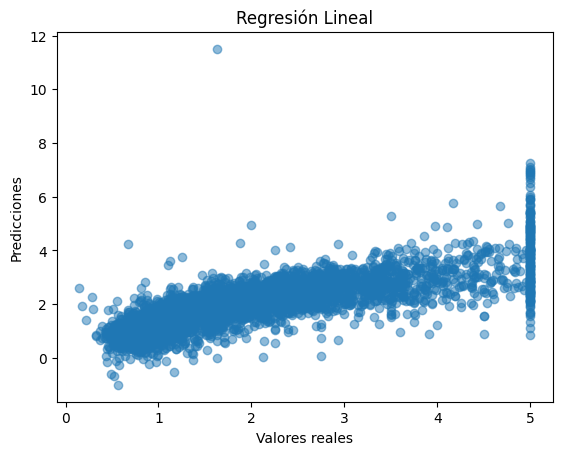

In [ ]:
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Lineal")
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
modelo_poly = LinearRegression()
modelo_poly.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_train_poly_pred = modelo_poly.predict(X_train_poly)
y_test_poly_pred = modelo_poly.predict(X_test_poly)

In [ ]:
mse_train_p, r2_train_p = evaluar(y_train, y_train_poly_pred)
mse_test_p, r2_test_p = evaluar(y_test, y_test_poly_pred)

print("REGRESIÓN POLINÓMICA")
print("Train -> MSE:", mse_train_p, "R2:", r2_train_p)
print("Test  -> MSE:", mse_test_p, "R2:", r2_test_p)

REGRESIÓN POLINÓMICA
Train -> MSE: 0.4207266151573583 R2: 0.6852681982344935
Test  -> MSE: 0.4643015261571134 R2: 0.6456819711504156


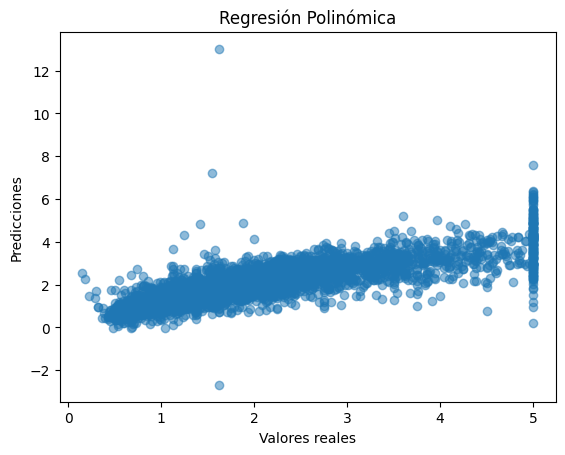

In [ ]:
plt.scatter(y_test, y_test_poly_pred, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Regresión Polinómica")
plt.show()

1.
* El modelo de regresión polinómica es mejor que el modelo de regresión lineal. Esto se determinó comparando las métricas en el conjunto de test, ya que estas reflejan la capacidad de generalización del modelo.

* El modelo polinómico obtuvo un menor MSE (0.464 frente a 0.556) y un mayor R² (0.646 frente a 0.576), lo que indica que comete menos errores y explica mejor la variabilidad de los datos.

* Esto sugiere que la relación entre las variables no es completamente lineal y que el modelo polinómico logra captarla mejor.

2.

* No se observan señales fuertes de overfitting en ninguno de los modelos.

* Esto se determina comparando el rendimiento entre el conjunto de entrenamiento y el de test. En ambos modelos, las métricas (MSE y R²) son similares entre train y test, lo que indica que los modelos generalizan adecuadamente a datos nuevos.

* En el caso del modelo polinómico, si bien presenta un mejor rendimiento en entrenamiento, la diferencia con el test no es significativa, por lo que no se considera que haya sobreajuste importante.

3.
* El impacto de cada feature se determinó analizando los coeficientes del modelo de regresión lineal. Cada coeficiente indica cuánto influye una variable en la predicción del precio.

* La variable con mayor impacto es aquella que tiene el coeficiente de mayor valor absoluto, ya que representa el mayor cambio en la variable objetivo ante una variación en esa feature.

* Esto se obtuvo utilizando los coeficientes del modelo (modelo_lineal.coef_) y asociándolos con los nombres de las variables.